In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from helper import plot_decision_boundary
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
%matplotlib inline
sns.set_style('white')


In [ ]:
# Read the dataset as a pandas dataframe
df = pd.read_csv("boostingclassifier.csv")

# Read the columns latitude and longitude as the predictor variables
X = df[['latitude','longitude']].values

# Landtype is the response variable
y = df['landtype'].values

In [ ]:
### edTest(test_response) ###
# update the class labels to appropriate values for AdaBoost
y = np.where(y=='A', -1, 1)

In [ ]:
# AdaBoost algorithm implementation from scratch

def AdaBoost_scratch(X, y, M=10):
    '''
    X: data matrix of predictors
    y: response variable
    M: number of estimators (e.g., 'stumps')
    '''

    # Initialization of utility variables
    N = len(y)
    estimator_list = []
    y_predict_list = []
    estimator_error_list = []
    estimator_weight_list = []
    sample_weight_list = []

    # Initialize the sample weights
    sample_weight = np.ones(N) / N

    # Store a copy of the sample weights to a list
    sample_weight_list.append(sample_weight.copy())

    for _ in range(M):
        # Instantiate a Decision Tree classifier for our stump
        # ADD random_state for reproducibility
        estimator = DecisionTreeClassifier(max_depth=1, random_state=42) # Added random_state

        # Fit the stump
        estimator.fit(X, y, sample_weight=sample_weight)

        # Predict
        y_predict = estimator.predict(X)

        # Misclassifications
        incorrect = (y_predict != y)

        # Error
        estimator_error = np.average(incorrect, weights=sample_weight)

        epsilon = 1e-10

        # Handle edge cases for error
        if estimator_error == 0:
             # If error is zero, assign a large positive weight
            estimator_weight = 1e6
        elif estimator_error >= 1: # Should not be > 1 with normalized weights
            # Assign a large negative weight
            estimator_weight = -1e6
        else:
            estimator_weight = 0.5 * np.log((1 - estimator_error + epsilon) / (estimator_error + epsilon))


        # Update sample weights (un-normalized)
        sample_weight *= np.exp(estimator_weight * incorrect)

        # Renormalize sample weights
        sample_weight_sum = sample_weight.sum()
        # Avoid division by zero if sample_weight_sum is exactly zero (unlikely but safe)
        if sample_weight_sum == 0:
             # If all sample weights are zero, reinitialize to uniform weights
             sample_weight = np.ones(N) / N
        else:
             sample_weight /= sample_weight_sum + epsilon


        # --- Modification to handle predict_proba (from previous step) ---
        original_predict_proba = estimator.predict_proba
        def wrapped_predict_proba(X):
            proba = original_predict_proba(X)
            if proba.shape[1] == 1:
                # Assume the single column is the probability of class 1 (positive class)
                two_column_proba = np.hstack((1 - proba, proba))
                return two_column_proba
            else:
                return proba
        estimator.predict_proba = wrapped_predict_proba
        # --- End of modification ---


        # Save iteration values
        estimator_list.append(estimator)
        y_predict_list.append(y_predict.copy())
        estimator_error_list.append(estimator_error.copy())
        estimator_weight_list.append(estimator_weight)
        sample_weight_list.append(sample_weight.copy())

    # Handle case where no estimators were added (e.g., M=0)
    if not estimator_list:
         return np.asarray([]), np.asarray([]), np.asarray([]), np.asarray([])


    # Convert to numpy arrays
    estimator_list = np.asarray(estimator_list, dtype=object)
    y_predict_list = np.asarray(y_predict_list)
    estimator_error_list = np.asarray(estimator_error_list)
    estimator_weight_list = np.asarray(estimator_weight_list)
    sample_weight_list = np.asarray(sample_weight_list)


    # Compute final predictions
    if estimator_list.size == 0:
        preds = np.zeros(N)
    else:
        weighted_predictions = y_predict_list.T * estimator_weight_list
        summed_weighted_predictions = weighted_predictions.sum(axis=1)
        preds = np.sign(summed_weighted_predictions)
        preds[preds == 0] = 1 # Convention for tie-breaking

    return estimator_list, estimator_weight_list, sample_weight_list, preds


In [ ]:
### edTest(test_adaboost) ###
# Call the AdaBoost function to perform boosting classification
estimator_list, estimator_weight_list, sample_weight_list, preds  = \
AdaBoost_scratch(X,y, M=9)

# Calculate the model's accuracy from the predictions returned above
accuracy = (preds == y).mean()
print(f'accuracy: {accuracy:.3f}')

accuracy: 1.000


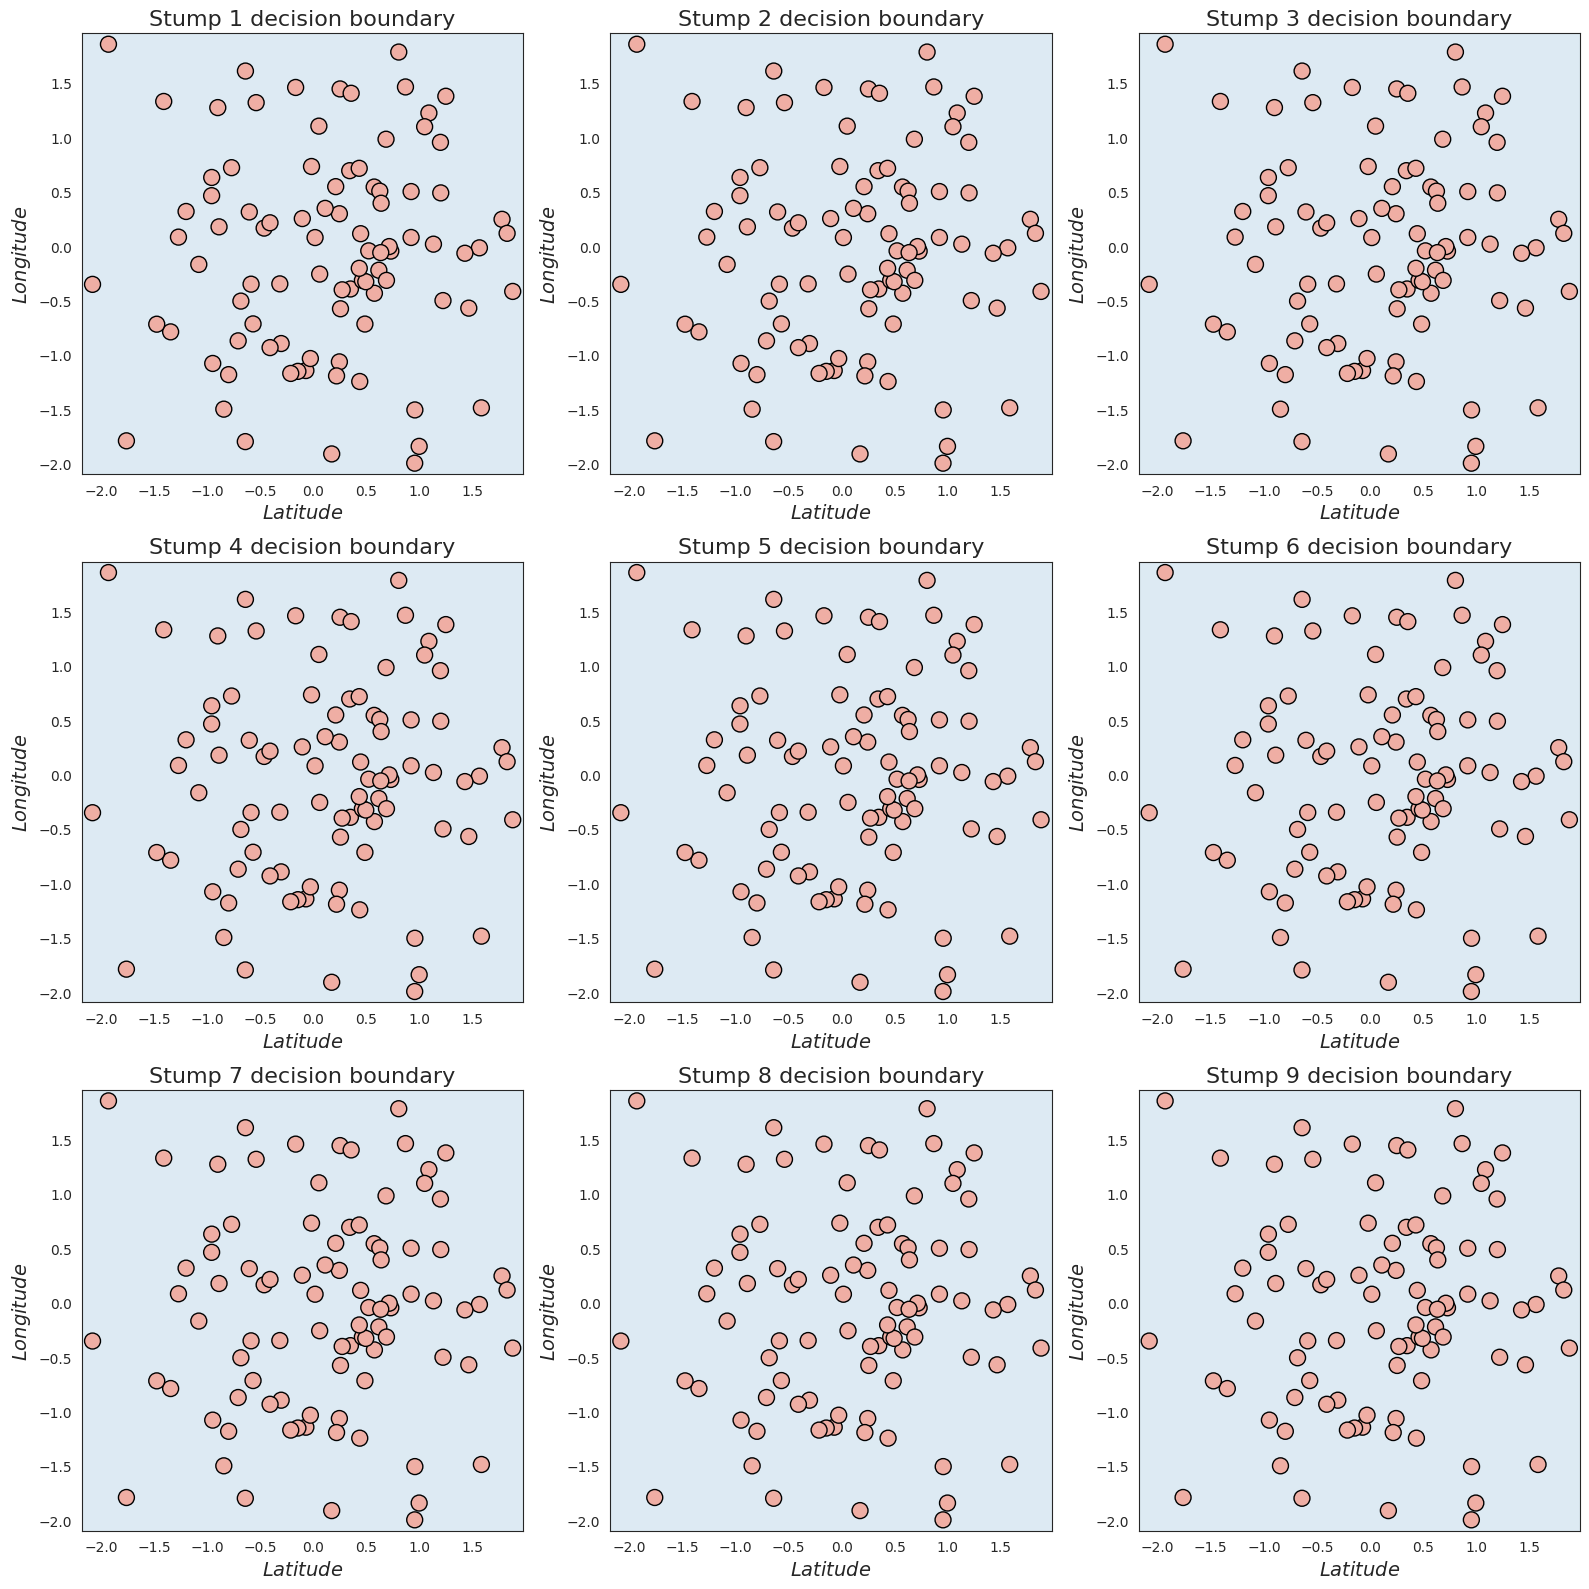

In [ ]:
# Helper code to plot the AdaBoost Decision Boundary stumps
fig = plt.figure(figsize = (16,16))
for m in range(0, 9):
    fig.add_subplot(3,3,m+1)
    s_weights = (sample_weight_list[m,:] / sample_weight_list[m,:].sum() ) * 300
    plot_decision_boundary(estimator_list[m], X,y,N = 50, scatter_weights =s_weights,counter=m)
    plt.tight_layout()


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


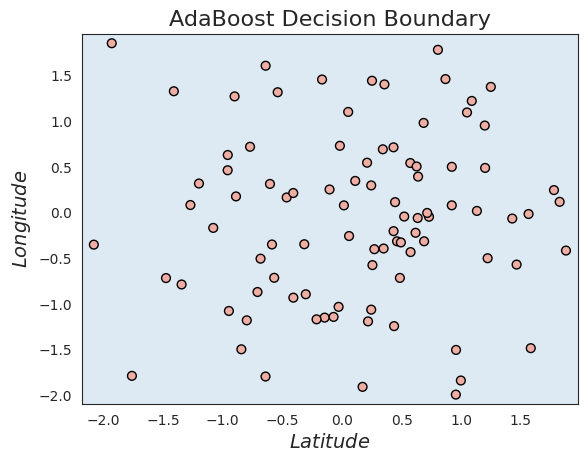

In [ ]:
# Use sklearn's AdaBoostClassifier to take a look at the final decision boundary

# Initialise the model with Decision Tree classifier as the base model same as above
# Use SAMME as the algorithm and 9 estimators
boost = AdaBoostClassifier( estimator = DecisionTreeClassifier(max_depth = 1),
                            algorithm = 'SAMME', n_estimators=9)

# Fit on the entire data
boost.fit(X,y)

# Call the plot_decision_boundary function to plot the decision boundary of the model
plot_decision_boundary(boost, X,y, N = 50)

plt.title('AdaBoost Decision Boundary', fontsize=16)
plt.show()


⏸ How does the `num_estimators` affect the model?

In [ ]:
### edTest(test_chow1) ###
# Type your answer within in the quotes given
answer1 = 'Increasing the number of estimators improves the model\'s performance by reducing bias, but can lead to overfitting if too large.'
